# Fraud Detection in Banking

In [3]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [5]:
df = pd.read_excel('FraudDetectionDataset.xlsx')
df.head()

,TransactionID,CustomerID,AccountAgeMonths,TransactionDate,TransactionType,Amount,MerchantCategory,Location,DeviceType,Channel,IsInternational,LoginAttempts,FailedOTP,CardPresent,Previous24hTxn,AvgMonthlySpend,RiskScore,IsFraud
0,T100002,C10194,19,2026-05-25 08:08,Online,152940.64,Shopping,Kolkata,Mobile,NetBanking,1,1,0,1,8,10339.34,22,0
1,T100003,C10278,128,2026-02-19 07:03,POS,51341.15,Fuel,Mumbai,Mobile,NetBanking,0,3,3,1,10,8254.64,46,0
2,T100004,C10049,82,2026-03-22 01:28,Bill Payment,12491.29,Dining,Hyderabad,ATM,NetBanking,0,2,2,0,18,11789.99,58,0
3,T100005,C10182,155,2026-06-06 09:06,ATM,195646.48,Fuel,Mumbai,Laptop,Debit Card,0,6,0,1,9,7022.75,3,0
4,T100006,C10270,158,2026-04-02 00:47,ATM,77578.03,Travel,Hyderabad,Mobile,Credit Card,0,3,3,1,9,90662.87,72,0


In [6]:
print(df.info())
print(df.describe(include='all'))
print(df['IsFraud'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TransactionID     500 non-null    str    
 1   CustomerID        500 non-null    str    
 2   AccountAgeMonths  500 non-null    int64  
 3   TransactionDate   500 non-null    str    
 4   TransactionType   500 non-null    str    
 5   Amount            500 non-null    float64
 6   MerchantCategory  500 non-null    str    
 7   Location          500 non-null    str    
 8   DeviceType        500 non-null    str    
 9   Channel           500 non-null    str    
 10  IsInternational   500 non-null    int64  
 11  LoginAttempts     500 non-null    int64  
 12  FailedOTP         500 non-null    int64  
 13  CardPresent       500 non-null    int64  
 14  Previous24hTxn    500 non-null    int64  
 15  AvgMonthlySpend   500 non-null    float64
 16  RiskScore         500 non-null    int64  
 17  IsFraud 

In [7]:
print(df.isnull().sum())

TransactionID       0
CustomerID          0
AccountAgeMonths    0
TransactionDate     0
TransactionType     0
Amount              0
MerchantCategory    0
Location            0
DeviceType          0
Channel             0
IsInternational     0
LoginAttempts       0
FailedOTP           0
CardPresent         0
Previous24hTxn      0
AvgMonthlySpend     0
RiskScore           0
IsFraud             0
dtype: int64


In [8]:
df = df.copy()
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_17180\725219461.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,TransactionID,CustomerID,AccountAgeMonths,TransactionDate,TransactionType,Amount,MerchantCategory,Location,DeviceType,Channel,IsInternational,LoginAttempts,FailedOTP,CardPresent,Previous24hTxn,AvgMonthlySpend,RiskScore,IsFraud
0,0,161,19,403,2,152940.64,4,4,2,2,1,1,0,1,8,10339.34,22,0
1,1,227,128,125,3,51341.15,2,5,2,2,0,3,3,1,10,8254.64,46,0
2,2,41,82,219,1,12491.29,0,3,0,2,0,2,2,0,18,11789.99,58,0
3,3,152,155,435,0,195646.48,2,5,1,1,0,6,0,1,9,7022.75,3,0
4,4,219,158,249,0,77578.03,5,3,2,0,0,3,3,1,9,90662.87,72,0


In [9]:
X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(400, 17) (100, 17)


In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))


Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.89      0.92      0.90        76
           1       0.71      0.62      0.67        24

    accuracy                           0.85       100
   macro avg       0.80      0.77      0.78       100
weighted avg       0.84      0.85      0.85       100

[[70  6]
 [ 9 15]]


C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))


Accuracy: 0.95
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        76
           1       0.83      1.00      0.91        24

    accuracy                           0.95       100
   macro avg       0.91      0.97      0.94       100
weighted avg       0.96      0.95      0.95       100

[[71  5]
 [ 0 24]]


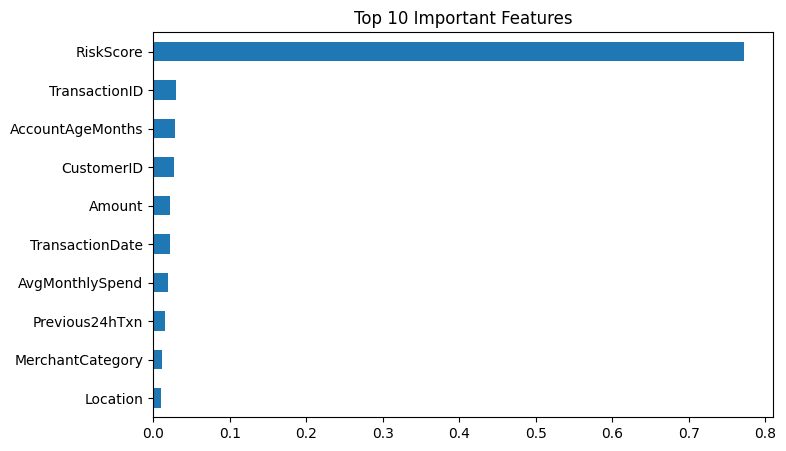

In [13]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().tail(10).plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Important Features')
plt.show()

In [14]:
sample = X.iloc[[0]]
prediction = rf.predict(sample)
print("Prediction:", "Fraud" if prediction[0]==1 else "Genuine")

Prediction: Genuine


In [ ]:
# ==========================================

# FRAUD DETECTION IN BANKING

# ==========================================

# Machine Learning Project

# Submitted By:

# N Charitha Reddy, Suhitha Chalasani

# ==========================================

# Project Overview

# ==========================================

# Banking fraud has become a major challenge in the digital

# era due to the increasing number of online transactions,

# mobile banking services, and digital payment platforms.

# Fraudulent activities can lead to significant financial

# losses for both customers and financial institutions.

# This project analyzes banking transaction data to identify

# suspicious patterns and develop machine learning models

# capable of distinguishing between genuine and fraudulent

# transactions.

# Project Objectives:

# 1. Data Collection and Preprocessing

# 2. Data Cleaning

# 3. Exploratory Data Analysis (EDA)

# 4. Feature Engineering

# 5. Data Visualization

# 6. Fraud Pattern Analysis

# 7. Machine Learning Model Development

# 8. Model Evaluation

# 9. Fraud Prediction

# 10. Conclusion

# ==========================================

# Problem Statement

# ==========================================

# Financial fraud is becoming increasingly sophisticated,

# making it difficult for traditional rule-based systems

# to detect fraudulent transactions accurately.

#

# The objective of this project is to build a machine

# learning model that can analyze banking transaction data

# and predict whether a transaction is genuine or fraudulent.

# The system aims to improve fraud detection accuracy while

# minimizing false alarms.

# ==========================================

# Dataset Description

# ==========================================

# The dataset contains various banking transaction details,

# including customer information, transaction attributes,

# account history, and fraud labels.

# Sample Features:

# - Transaction ID

# - Customer ID

# - Transaction Amount

# - Transaction Type

# - Merchant Category

# - Transaction Date

# - Location

# - Device Type

# - Banking Channel

# - Card Present

# - International Transaction

# - Login Attempts

# - Failed OTP Attempts

# - Previous Transactions (24 Hours)

# - Average Monthly Spending

# - Risk Score

# - Fraud Status (Target Variable)

# ==========================================

# Tools & Technologies Used

# ==========================================

# - Python

# - Jupyter Notebook / Google Colab

# - Pandas

# - NumPy

# - Matplotlib

# - Seaborn

# - Scikit-learn

# ==========================================

# Machine Learning Algorithms

# ==========================================

# - Logistic Regression

# - Random Forest Classifier

# - Decision Tree (Optional)

# - Support Vector Machine (Optional)

# ==========================================

# Project Workflow

# ==========================================

# 1. Import Required Libraries

# 2. Load Dataset

# 3. Data Cleaning

# 4. Handle Missing Values

# 5. Encode Categorical Variables

# 6. Exploratory Data Analysis

# 7. Data Visualization

# 8. Feature Selection

# 9. Train-Test Split

# 10. Model Training

# 11. Model Evaluation

# 12. Fraud Prediction

# 13. Conclusion

# ==========================================

# Expected Outcome

# ==========================================

# The developed machine learning model should accurately

# classify banking transactions as either genuine or

# fraudulent. The project also provides valuable insights

# into the factors that contribute to fraudulent activities,

# helping financial institutions strengthen fraud prevention

# strategies.
